In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("clients.csv")

In [4]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [5]:
df.shape

(2000, 12)

In [6]:
df.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [8]:
df.describe()

,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [9]:
df.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], format='mixed')

In [12]:
df['date_of_birth'].head()

,date_of_birth
0,1968-05-11
1,1962-11-26
2,1959-04-07
3,1959-11-25
4,1976-02-28


In [14]:
from datetime import datetime

In [16]:
df['Age'] = datetime.now().year - df['date_of_birth'].dt.year

In [17]:
df[['date_of_birth', 'Age']].head()

,date_of_birth,Age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50


In [18]:
df = df.drop('date_of_birth', axis=1)

In [19]:
df.head()

,client_id,client_type,first_name,last_name,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age
0,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,Website,58
1,C0002,Individual,Trystan,Oconnor,M,USA,California,Home,1,No,Website,64
2,C0003,Individual,Kale,Gay,M,USA,California,Home,4,Yes,Agency,67
3,C0004,Individual,Russell,Gross,M,USA,California,Home,5,No,Website,67
4,C0005,Company,Marleez,Co,M,USA,California,Investment,5,No,Website,50


In [20]:
df.dtypes

,0
client_id,object
client_type,object
first_name,object
last_name,object
gender,object
country,object
region,object
acquisition_purpose,object
satisfaction_score,int64
loan_applied,object


In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()

In [24]:
df['client_type'] = le.fit_transform(df['client_type'])

In [25]:
df[['client_type']].head()

,client_type
0,1
1,1
2,1
3,1
4,0


In [27]:
df['gender'] = le.fit_transform(df['gender'])

In [28]:
df['loan_applied'] = le.fit_transform(df['loan_applied'])

In [29]:
df = pd.get_dummies(df, columns=['country', 'region', 'acquisition_purpose', 'referral_channel'])

In [30]:
df.head()

,client_id,client_type,first_name,last_name,gender,satisfaction_score,loan_applied,Age,country_Australia,country_Belgium,...,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,C0001,1,Kareem,Liu,0,4,1,58,False,False,...,False,False,False,False,False,True,False,False,False,True
1,C0002,1,Trystan,Oconnor,1,1,0,64,False,False,...,False,False,False,False,False,True,False,False,False,True
2,C0003,1,Kale,Gay,1,4,1,67,False,False,...,False,False,False,False,False,True,False,True,False,False
3,C0004,1,Russell,Gross,1,5,0,67,False,False,...,False,False,False,False,False,True,False,False,False,True
4,C0005,0,Marleez,Co,1,5,0,50,False,False,...,False,False,False,False,False,False,True,False,False,True


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [34]:
df = df.drop(['client_id', 'first_name', 'last_name'], axis=1)

In [35]:
scaled_data = scaler.fit_transform(df)

In [36]:
from sklearn.cluster import KMeans

In [37]:
wcss = []

In [38]:
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

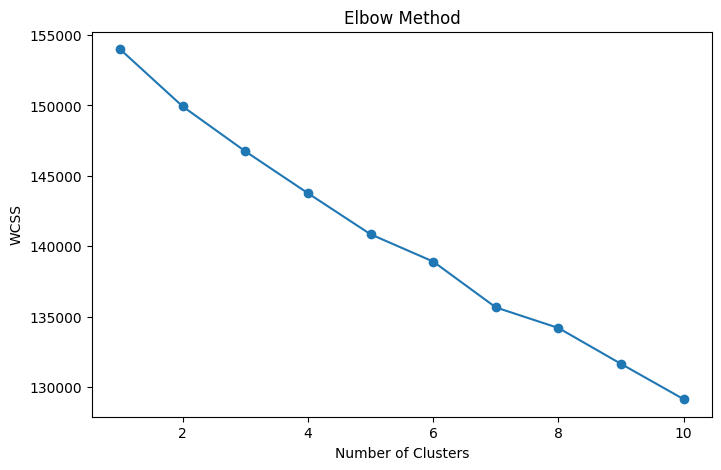

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

In [41]:
df['Cluster'].value_counts()

,count
Cluster,
2,1473
0,454
3,65
1,8


In [42]:
df.groupby('Cluster').mean(numeric_only=True)

,client_type,gender,satisfaction_score,loan_applied,Age,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,...,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,referral_channel_Agency,referral_channel_Client,referral_channel_Website
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.949339,0.522026,3.026432,0.376652,54.612335,0.085903,0.094714,0.187225,0.03304,0.11674,...,0.03304,0.000000,0.013216,0.000000,0.004405,0.682819,0.317181,0.334802,0.096916,0.568282
1,1.000000,0.375000,2.875000,0.125000,62.250000,0.000000,0.000000,0.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.875000,0.125000,0.375000,0.000000,0.625000
2,0.948405,0.503055,3.023761,0.369314,56.657162,0.000000,0.000000,0.000000,0.00000,0.00000,...,0.00000,0.049559,0.000000,0.000679,0.000000,0.694501,0.305499,0.357094,0.097081,0.545825
3,0.938462,0.476923,3.184615,0.307692,53.076923,0.000000,0.000000,0.000000,0.00000,0.00000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.692308,0.307692,0.369231,0.076923,0.553846


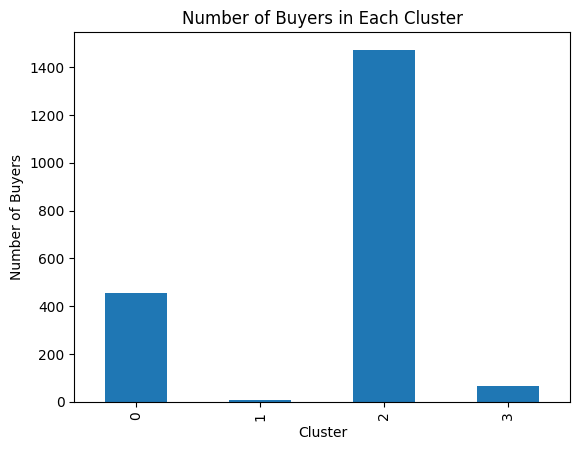

In [43]:
import matplotlib.pyplot as plt

df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Buyers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")
plt.show()

<Figure size 800x500 with 0 Axes>

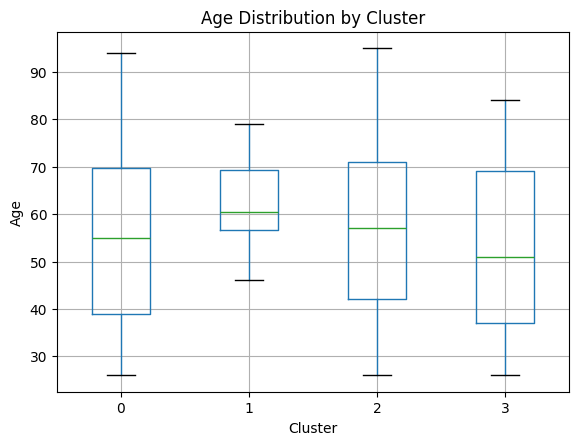

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column='Age', by='Cluster')
plt.title("Age Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Age")
plt.show()

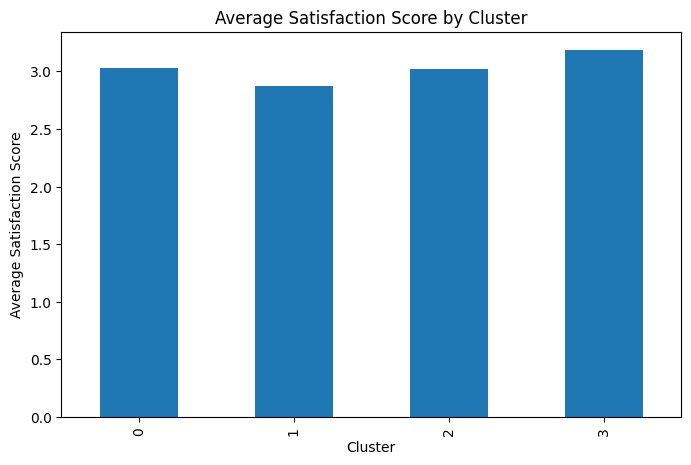

In [45]:
plt.figure(figsize=(8,5))
df.groupby('Cluster')['satisfaction_score'].mean().plot(kind='bar')
plt.title("Average Satisfaction Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Satisfaction Score")
plt.show()

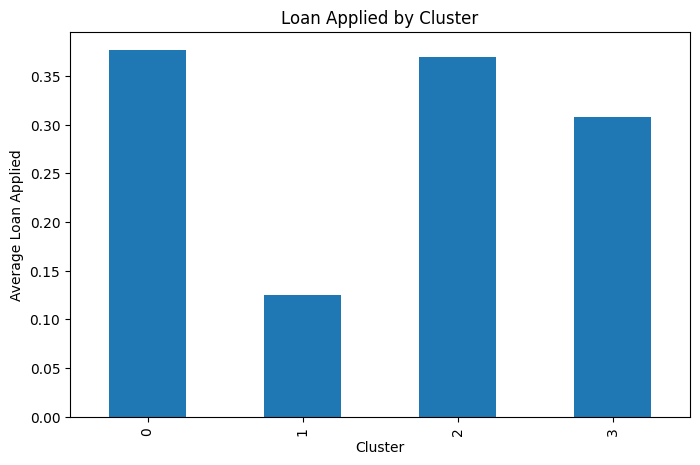

In [46]:
plt.figure(figsize=(8,5))
df.groupby('Cluster')['loan_applied'].mean().plot(kind='bar')
plt.title("Loan Applied by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Loan Applied")
plt.show()

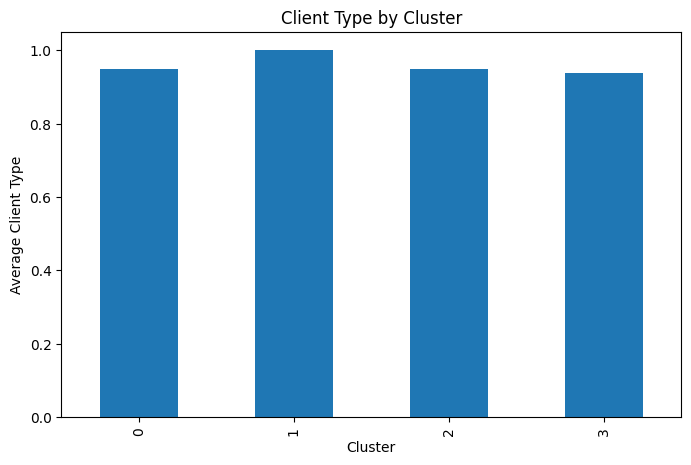

In [47]:
plt.figure(figsize=(8,5))
df.groupby('Cluster')['client_type'].mean().plot(kind='bar')
plt.title("Client Type by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Client Type")
plt.show()

In [48]:
df.to_csv("buyer_segmentation_results.csv", index=False)

In [49]:
df.head(10)

,client_type,gender,satisfaction_score,loan_applied,Age,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,...,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,referral_channel_Agency,referral_channel_Client,referral_channel_Website,Cluster
0,1,0,4,1,58,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,2
1,1,1,1,0,64,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,2
2,1,1,4,1,67,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,2
3,1,1,5,0,67,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,2
4,0,1,5,0,50,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,2
5,1,1,3,1,69,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,2
6,1,1,5,0,79,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,0
7,1,0,5,0,57,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,2
8,1,1,5,0,51,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,2
9,1,1,3,0,60,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,2


In [50]:
df['Cluster'].value_counts()

,count
Cluster,
2,1473
0,454
3,65
1,8


In [51]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 88.3 MB/s eta 0:00:00


In [54]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as pltst.title("Buyer Segmentation Dashboard")

df = pd.read_csv("buyer_segmentation_results.csv")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Cluster Distribution")
st.bar_chart(df["Cluster"].value_counts())

st.subheader("Average Satisfaction Score by Cluster")
st.bar_chart(df.groupby("Cluster")["satisfaction_score"].mean())

st.subheader("Loan Applied by Cluster")
st.bar_chart(df.groupby("Cluster")["loan_applied"].sum())

st.subheader("Country Distribution")
st.bar_chart(df["country"].value_counts())

st.success("Dashboard Created Successfully!")

Overwriting app.py


In [55]:
!pip install pyngrok

In [58]:
from pyngrok import ngrok
import subprocess

subprocess.Popen(["streamlit", "run", "app.py"])

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://coke-impulsive-identical.ngrok-free.dev" -> "http://localhost:8501"


In [57]:
from pyngrok import ngrok

ngrok.set_auth_token("3FrMNmhMx9a6de9U1wRm2spSy8k_MXhgpKjcaFcQ2wEexYdk")

In [60]:
from pyngrok import ngrok
import subprocess

# If a tunnel already exists, close it
ngrok.kill()

subprocess.Popen(["streamlit", "run", "app.py"])

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://coke-impulsive-identical.ngrok-free.dev" -> "http://localhost:8501"


In [62]:
print(df.columns.tolist())

['client_type', 'gender', 'satisfaction_score', 'loan_applied', 'Age', 'country_Australia', 'country_Belgium', 'country_Canada', 'country_Denmark', 'country_France', 'country_Germany', 'country_Mexico', 'country_Russia', 'country_UK', 'country_USA', 'region_Alberta', 'region_Arizona', 'region_Baja California', 'region_Bavaria', 'region_Berlin', 'region_British Columbia', 'region_Brittany', 'region_Brussels', 'region_California', 'region_Capital Region', 'region_Central Denmark', 'region_Colorado', 'region_England', 'region_Flanders', 'region_Florida', 'region_Georgia', 'region_Hamburg', 'region_Hesse', 'region_Ile-de-France', 'region_Jalisco', 'region_Kansas', 'region_Krasnodar Krai', 'region_Manitoba', 'region_Mexico City', 'region_Moscow Oblast', 'region_Nevada', 'region_New South Wales', 'region_New York', 'region_Normandy', 'region_North Denmark', 'region_North Rhine-Westphalia', 'region_Northern Ireland', 'region_Novosibirsk', 'region_Nuevo Leon', 'region_Occitanie', 'region_Ohio'